In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
### Geometric Brownian Motion
S0 = 100
mu = 0.05
sigma = 0.20

T = 1
steps = 252
simulations = 10000


dt = T / steps

In [3]:
#### shocks
Z = np.random.normal(
    0,
    1,
    (steps, simulations)
)


Z.shape

(252, 10000)

In [4]:
#GBM simulation
prices = np.zeros(
    (steps+1, simulations)
)


prices[0] = S0



for t in range(1, steps+1):

    prices[t] = prices[t-1] * np.exp(

        (mu - 0.5*sigma**2)*dt

        +

        sigma*np.sqrt(dt)*Z[t-1]

    )

In [5]:
prices.shape

(253, 10000)

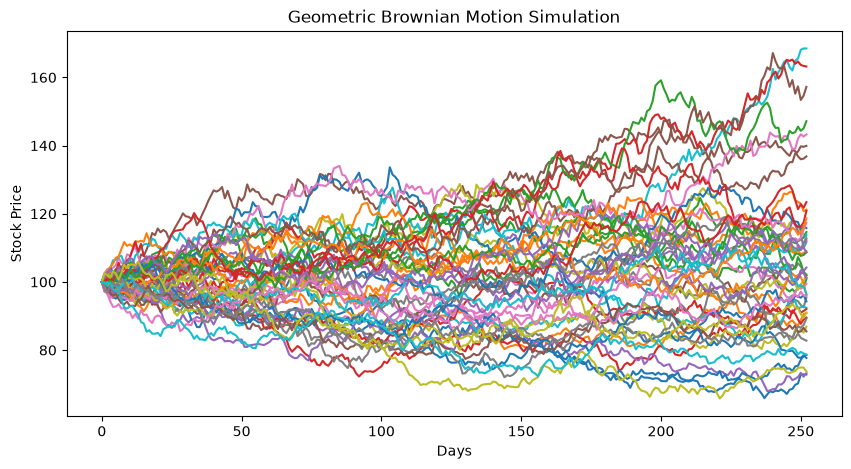

In [6]:
plt.figure(figsize=(10,5))


plt.plot(
    prices[:, :50]
)


plt.title(
    "Geometric Brownian Motion Simulation"
)


plt.xlabel(
    "Days"
)


plt.ylabel(
    "Stock Price"
)


plt.show()

#### Terminal Price Distribution

In [7]:
terminal_prices = prices[-1]


terminal_prices[:10]

array([ 72.83330506,  90.85116388, 100.80137651,  89.5352524 ,
        73.26258887, 136.82509054, 112.15258108,  95.42060566,
       112.81342012,  92.38226695])

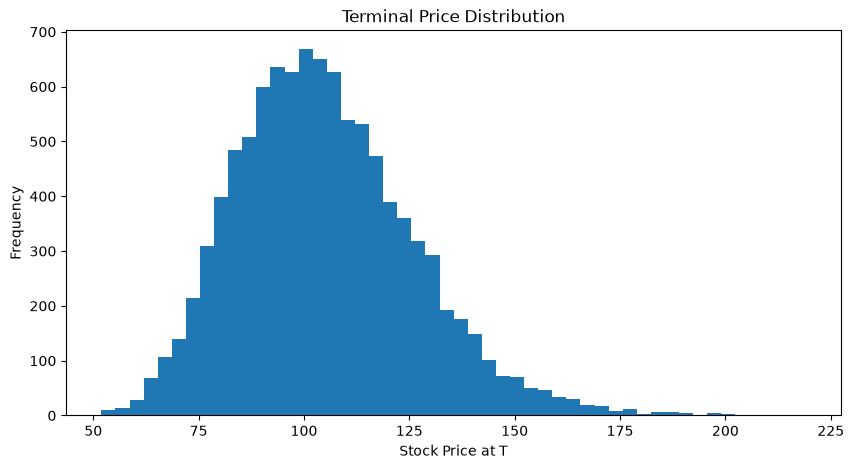

In [8]:
plt.figure(figsize=(10,5))


plt.hist(
    terminal_prices,
    bins=50
)


plt.title(
    "Terminal Price Distribution"
)


plt.xlabel(
    "Stock Price at T"
)


plt.ylabel(
    "Frequency"
)


plt.show()

### Statistics

In [9]:
print(
    "Mean:",
    terminal_prices.mean()
)


print(
    "Median:",
    np.median(terminal_prices)
)


print(
    "Std:",
    terminal_prices.std()
)


print(
    "Min:",
    terminal_prices.min()
)


print(
    "Max:",
    terminal_prices.max()
)

Mean: 104.96336341891316
Median: 102.93303995996496
Std: 21.110263862412623
Min: 51.926160330606436
Max: 219.10923550548


#### European Call Option Pricing

In [10]:
K = 100       # strike price

r = 0.05       # risk free rate

T = 1

In [11]:
payoffs = np.maximum(
    terminal_prices - K,
    0
)


payoffs[:10]

array([ 0.        ,  0.        ,  0.80137651,  0.        ,  0.        ,
       36.82509054, 12.15258108,  0.        , 12.81342012,  0.        ])

In [12]:
call_price_mc = np.exp(
    -r*T
) * payoffs.mean()


call_price_mc

np.float64(10.339890818869339)

In [13]:
probability_ITM = (
    terminal_prices > K
).mean()


probability_ITM

np.float64(0.5603)

#### Black-Scholes Analytical Solution

In [14]:
from scipy.stats import norm
import numpy as np

def black_scholes_call(
    S0,
    K,
    r,
    sigma,
    T
):

    d1 = (
        np.log(S0/K)
        +
        (r + 0.5*sigma**2)*T
    ) / (
        sigma*np.sqrt(T)
    )


    d2 = (
        d1
        -
        sigma*np.sqrt(T)
    )


    call = (
        S0*norm.cdf(d1)
        -
        K*np.exp(-r*T)*norm.cdf(d2)
    )


    return call

In [15]:
bs_price = black_scholes_call(
    S0,
    K,
    r,
    sigma,
    T
)


bs_price

np.float64(10.450583572185565)

In [16]:
print(
    "Monte Carlo:",
    call_price_mc
)


print(
    "Black-Scholes:",
    bs_price
)


print(
    "Difference:",
    call_price_mc - bs_price
)

Monte Carlo: 10.339890818869339
Black-Scholes: 10.450583572185565
Difference: -0.11069275331622563


#### Convergence Analysis

In [17]:
simulation_sizes = [
    1000,
    5000,
    10000,
    50000,
    100000
]


results = []

In [18]:
for n in simulation_sizes:

    Z = np.random.normal(
        0,
        1,
        (steps,n)
    )


    prices = np.zeros(
        (steps+1,n)
    )


    prices[0] = S0


    for t in range(1, steps+1):

        prices[t] = prices[t-1] * np.exp(

            (mu-0.5*sigma**2)*dt

            +

            sigma*np.sqrt(dt)*Z[t-1]

        )


    terminal = prices[-1]


    payoff = np.maximum(
        terminal-K,
        0
    )


    mc_price = np.exp(
        -r*T
    ) * payoff.mean()


    error = abs(
        mc_price-bs_price
    )


    results.append(
        [
            n,
            mc_price,
            error
        ]
    )

In [19]:
import pandas as pd


convergence = pd.DataFrame(

    results,

    columns=[
        "Simulations",
        "Monte Carlo Price",
        "Absolute Error"
    ]

)


convergence

,Simulations,Monte Carlo Price,Absolute Error
0,1000,9.946844,0.503740
1,5000,10.954161,0.503578
2,10000,10.189197,0.261386
3,50000,10.384788,0.065795
4,100000,10.384491,0.066093


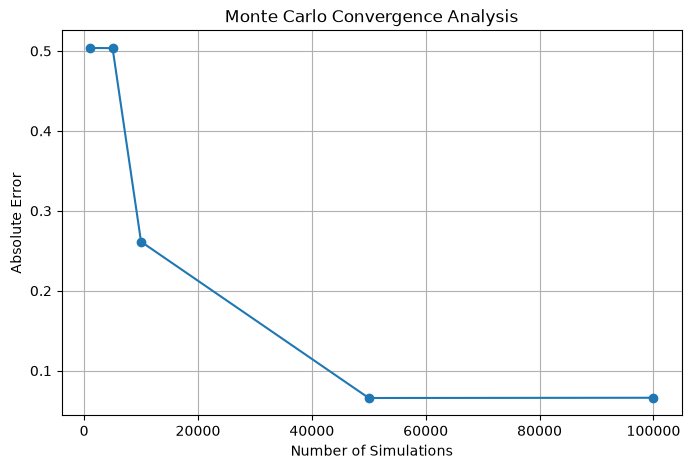

In [20]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.plot(
    convergence["Simulations"],
    convergence["Absolute Error"],
    marker="o"
)


plt.xlabel(
    "Number of Simulations"
)


plt.ylabel(
    "Absolute Error"
)


plt.title(
    "Monte Carlo Convergence Analysis"
)


plt.grid()


plt.show()

### Confidence Interval

In [21]:
# Confidence Interval for Monte Carlo price

discounted_payoffs = np.exp(
    -r*T
) * payoffs


mc_mean = discounted_payoffs.mean()


mc_std = discounted_payoffs.std(
    ddof=1
)


N = len(discounted_payoffs)


standard_error = mc_std / np.sqrt(N)


lower = mc_mean - 1.96 * standard_error

upper = mc_mean + 1.96 * standard_error


print(
    "Monte Carlo Price:",
    mc_mean
)


print(
    "95% Confidence Interval:"
)


print(
    lower,
    upper
)

Monte Carlo Price: 10.33989081886934
95% Confidence Interval:
10.054966186161115 10.624815451577566


###### Testing scr modules

In [23]:
import sys
import os

sys.path.append(
    os.path.abspath("../")
)

from src.brownian_motion import simulate_gbm

In [24]:
paths = simulate_gbm(

    S0=100,

    mu=0.05,

    sigma=0.20,

    T=1,

    steps=252,

    simulations=10000,

    seed=42

)

In [25]:
terminal_prices = paths[-1]

terminal_prices.mean()

np.float64(104.96194184518582)

In [26]:
from src.black_scholes import black_scholes_call

In [27]:
bs_price = black_scholes_call(
    S0=100,
    K=100,
    r=0.05,
    sigma=0.20,
    T=1
)


bs_price

np.float64(10.450583572185565)

In [28]:
from src.monte_carlo import european_call_mc

In [29]:
mc_price = european_call_mc(
    terminal_prices,
    K=100,
    r=0.05,
    T=1
)


mc_price

np.float64(10.344344101715956)

In [30]:
from src.statistics import confidence_interval, pricing_error

In [31]:
payoffs = np.maximum(
    terminal_prices - 100,
    0
)


discounted_payoffs = np.exp(
    -0.05
) * payoffs



confidence_interval(
    discounted_payoffs
)

(np.float64(10.344344101715954),
 np.float64(10.059738629651736),
 np.float64(10.628949573780172))

In [32]:
pricing_error(
    10.344344101715956,
    10.450583572185565
)

0.10623947046960858

In [33]:
from src.plotting import (
    plot_gbm_paths,
    plot_terminal_distribution,
    plot_convergence
)

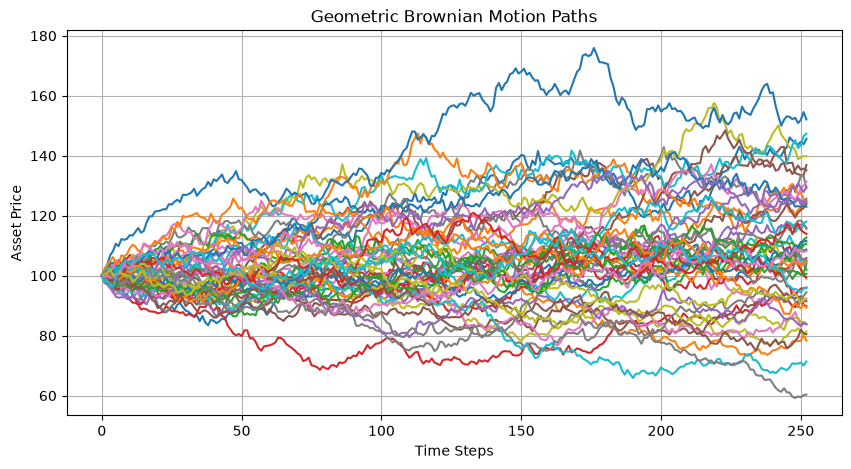

In [34]:
plot_gbm_paths(
    paths
)

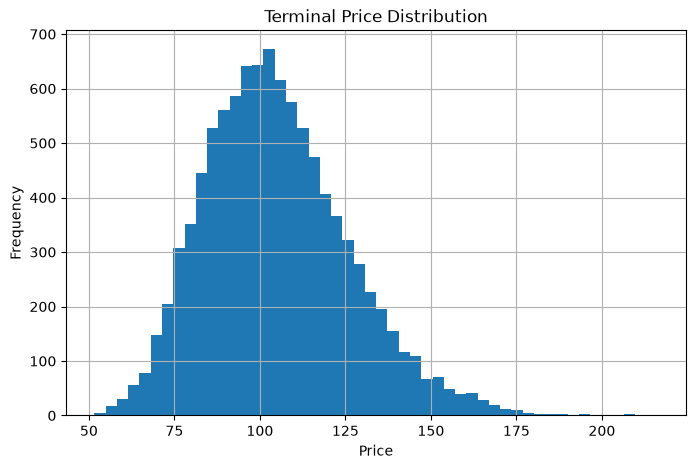

In [35]:
plot_terminal_distribution(
    terminal_prices
)